In [2]:
%load_ext autoreload
%autoreload 2
import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
import os
import networkx as nx
from networkx.algorithms.connectivity import edge_connectivity
import re
from pathlib import Path


sys.setrecursionlimit(10**6)
warnings.filterwarnings('ignore')
datadir = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_ConstantStress/Data/'
plotsdir = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_ConstantStress/Plots/'
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs3 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']

cmap3 = plt.cm.get_cmap('BuPu')
cmap3 = plt.cm.get_cmap('twilight')
cmap3 = plt.cm.get_cmap('PiYG')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
Presses = "-0.1".split()
#Presses = "-0.05".split()
MPs = "0.0 0.01 0.01".split() #0.1 0.01 0.001 0.0001 0.00001 0.00001 
labels = ["i. No bond remodelling","ii. Remodel no new material","iii. Remodel + new material"]
NuMons = "5 5 5".split()
lw = 2
cmap = plt.get_cmap('magma')
lines = ['-',':','--','-.']
clrs = ['#fdae61','#2b83ba','#abdda4']

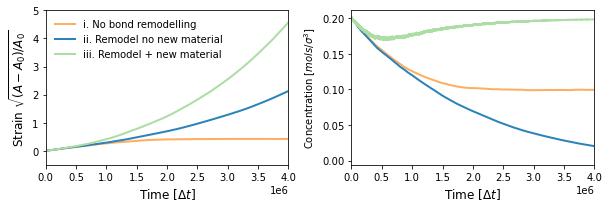

In [9]:
def plot_three_condition_files(
    files,
    labels,
    clrs,
    lw=2,
    xlim=None,          # e.g. (0, 4e6)
    figsize=(8, 3.0),
):
    """
    files: list of 3 paths (one per condition), each has columns:
           Time Strain Concentration (space-separated)
    Produces a figure with 2 subplots: strain and concentration vs time.
    """
    fig, ax = plt.subplots(1, 2, figsize=figsize, sharex=True)

    for i, fp in enumerate(files):
        fp = Path(fp)
        if not fp.exists():
            print("Missing:", fp)
            continue

        df = pandas.read_csv(fp, sep=r"\s+", engine="python")
        # robust numeric conversion + sort
        t = pandas.to_numeric(df["Time"], errors="coerce").to_numpy(dtype=float)
        strain = pandas.to_numeric(df["Strain"], errors="coerce").to_numpy(dtype=float)
        conc = pandas.to_numeric(df["Concentration"], errors="coerce").to_numpy(dtype=float)

        mask = np.isfinite(t) & np.isfinite(strain) & np.isfinite(conc)
        t, strain, conc = t[mask], strain[mask], conc[mask]

        order = np.argsort(t)
        t, strain, conc = t[order], strain[order], conc[order]

        ax[0].plot(t, strain, color=clrs[i], linewidth=lw, label=labels[i])
        ax[1].plot(t, conc,   color=clrs[i], linewidth=lw, label=labels[i])

    ax[0].set_xlabel(r"Time [$\Delta t$]", fontsize=12)
    ax[1].set_xlabel(r"Time [$\Delta t$]", fontsize=12)

    ax[0].set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$",fontsize = 12)
    ax[1].set_ylabel(r"Concentration [$mols/\sigma^3$]")

    ax[0].legend(frameon=False, fontsize=10)

    if xlim is not None:
        ax[0].set_xlim(xlim)
    ax[0].set_ylim([-0.5,5])

    fig.tight_layout()
    return fig, ax


# -------- Example usage --------
# same outdir as saving step
outdir = Path(datadir) 

# If you used the same naming scheme I gave:
safe_labels = [
    labels[0].replace(" ", "_").replace(".", "").replace("+", "plus").replace(":", ""),
    labels[1].replace(" ", "_").replace(".", "").replace("+", "plus").replace(":", ""),
    labels[2].replace(" ", "_").replace(".", "").replace("+", "plus").replace(":", ""),
]

files = [
    outdir / f"Condition_1_{safe_labels[0]}.dat",
    outdir / f"Condition_2_{safe_labels[1]}.dat",
    outdir / f"Condition_3_{safe_labels[2]}.dat",
]

figNICE2, axNICE2 = plot_three_condition_files(
    files=files,
    labels=labels,
    clrs=clrs,
    lw=2,
    xlim=(0, 4e6),
    figsize=(8.5, 3.0),
)

# Save if you want
# figNICE2.savefig(Path(plotsdir) / "Three_Regimes_StrCon_fromFiles.pdf")
